# AQSM Embedding + Extraction Testbench

Runs a 50-example `r = 1` test set from the USC-SIPI images already configured in this repo, then compares each original watermark with the extracted watermark.


In [1]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

from aqsm_embedding import (
    AQSMWatermarkBuilder,
    BitPlaneDecomposer,
    HDWMEmbedder,
    HDWMExtractor,
    HistogramAnalyzer,
    ImageFileLoader,
    ScaleParameterCalculator,
    USCSIPISampleDataset,
)

NUM_TRIALS = 50
MAX_IMAGE_RESULTS_PER_BRANCH = 3
USE_DERIVED_DARK_BRANCH_VARIANTS = True
HISTOGRAM_DENOMINATOR_MODE = "natural"
CACHE_DIR = Path("example_outputs") / "usc_sipi_samples"
BRANCH_ORDER = ("tau1=0", "tau1=1,tau2=1", "tau1=1,tau2=0")

plt.rcParams["figure.dpi"] = 120


In [2]:
def branch_label(parameters):
    if parameters.tau1 == 0:
        return "tau1=0"
    return f"tau1=1,tau2={parameters.tau2}"


def invert_image(image):
    return [[255 - value for value in row] for row in image]


def pixel_difference_percent(original, recovered):
    total = len(original) * len(original[0])
    different = sum(
        1
        for row_index, row in enumerate(original)
        for column_index, value in enumerate(row)
        if value != recovered[row_index][column_index]
    )
    return 100 * different / total


def max_abs_difference(original, recovered):
    return max(
        abs(value - recovered[row_index][column_index])
        for row_index, row in enumerate(original)
        for column_index, value in enumerate(row)
    )


def difference_map(original, recovered):
    return [
        [255 if value != recovered[row_index][column_index] else 0 for column_index, value in enumerate(row)]
        for row_index, row in enumerate(original)
    ]


def print_options(title, options):
    print(title)
    for index, (key, spec) in enumerate(options.items(), start=1):
        print(f"  {index:02d}. {key:<34} {spec.image_id:<10} {spec.description}")


def show_result(record):
    fig, axes = plt.subplots(1, 3, figsize=(7.6, 2.6))
    images = (
        record["watermark_image"],
        record["recovered_watermark"],
        record["diff_map"],
    )
    titles = (
        "Original watermark",
        f"Extracted watermark\n{record['diff_percent']:.6f}% different",
        "Difference map",
    )
    for axis, image, title in zip(axes, images, titles):
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title, fontsize=8)
        axis.axis("off")
    fig.suptitle(
        f"Trial {record['trial_id']:02d}: {record['branch']} | {record['watermark_key']} -> {record['carrier_key']}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


In [3]:
dataset = USCSIPISampleDataset(CACHE_DIR)
watermark_options = dataset.watermark_options()
carrier_options = dataset.carrier_options()

natural_pair_count = len(watermark_options) * len(carrier_options)
print(f"Natural 256x256 watermark images available: {len(watermark_options)}")
print(f"Natural 512x512 carrier images available:   {len(carrier_options)}")
print(f"Natural r=1 watermark/carrier pairs:        {natural_pair_count}")
print(f"Requested test trials:                      {NUM_TRIALS}")
print()
print_options("Watermark options you can pick from:", watermark_options)
print()
print_options("Carrier options you can pick from:", carrier_options)


Natural 256x256 watermark images available: 6
Natural 512x512 carrier images available:   16
Natural r=1 watermark/carrier pairs:        96
Requested test trials:                      50

Watermark options you can pick from:
  01. watermark_moon_256                 5.1.09     Moon surface, 256x256 grayscale
  02. watermark_aerial_256               5.1.10     Aerial, 256x256 grayscale
  03. watermark_airplane_256             5.1.11     Airplane, 256x256 grayscale
  04. watermark_clock_256                5.1.12     Clock, 256x256 grayscale
  05. watermark_resolution_chart_256     5.1.13     Resolution chart, 256x256 grayscale
  06. watermark_chemical_plant_256       5.1.14     Chemical plant, 256x256 grayscale

Carrier options you can pick from:
  01. carrier_couple_512                 5.2.08     Couple, 512x512 grayscale
  02. carrier_aerial_512                 5.2.09     Aerial, 512x512 grayscale
  03. carrier_bridge_512                 5.2.10     Stream and bridge, 512x512 grayscale
 

In [4]:
loader = ImageFileLoader()

watermark_paths = {key: dataset.download_sample(key) for key in watermark_options}
carrier_paths = {key: dataset.download_sample(key) for key in carrier_options}

watermarks = {
    key: loader.load_grayscale(path, target_side=256)
    for key, path in watermark_paths.items()
}
carriers = {
    key: loader.load_grayscale(path, target_side=512)
    for key, path in carrier_paths.items()
}

print(f"Loaded {len(watermarks)} watermarks and {len(carriers)} carriers.")


Loaded 6 watermarks and 16 carriers.


In [5]:
histogram_analyzer = HistogramAnalyzer()
scale_calculator = ScaleParameterCalculator()
reference_carrier = next(iter(carriers.values()))


def analyze_watermark_variant(key, source_key, description, image, variant_kind):
    scale_parameters = scale_calculator.compute(image, reference_carrier)
    histogram_parameters = histogram_analyzer.analyze(
        image,
        scale_parameters,
        denominator_mode=HISTOGRAM_DENOMINATOR_MODE,
    )
    return {
        "key": key,
        "source_key": source_key,
        "description": description,
        "variant_kind": variant_kind,
        "image": image,
        "histogram_parameters": histogram_parameters,
        "branch": branch_label(histogram_parameters),
    }


natural_variants = [
    analyze_watermark_variant(
        key=key,
        source_key=key,
        description=watermark_options[key].description,
        image=image,
        variant_kind="natural",
    )
    for key, image in watermarks.items()
]

natural_by_branch = defaultdict(list)
for variant in natural_variants:
    natural_by_branch[variant["branch"]].append(variant)

print("Natural watermark branch coverage:")
for branch in BRANCH_ORDER:
    names = ", ".join(variant["key"] for variant in natural_by_branch.get(branch, [])) or "none"
    print(f"  {branch:<13} {len(natural_by_branch.get(branch, [])):>2} watermark(s): {names}")

variant_pool = list(natural_variants)
if USE_DERIVED_DARK_BRANCH_VARIANTS:
    dark_branch_added = []
    for variant in natural_variants:
        inverted = analyze_watermark_variant(
            key=f"inverted_{variant['source_key']}",
            source_key=variant["source_key"],
            description=f"Inverted {variant['description']}",
            image=invert_image(variant["image"]),
            variant_kind="derived_inverted",
        )
        if inverted["branch"] == "tau1=1,tau2=0":
            variant_pool.append(inverted)
            dark_branch_added.append(inverted["key"])
    if dark_branch_added:
        print()
        print("No natural USC-SIPI watermark in this configured set hits tau1=1,tau2=0.")
        print("Added dataset-derived inverted variants for that branch:")
        for key in dark_branch_added:
            print(f"  {key}")

variants_by_branch = defaultdict(list)
for variant in variant_pool:
    variants_by_branch[variant["branch"]].append(variant)

print()
print("Testbench branch coverage:")
for branch in BRANCH_ORDER:
    names = ", ".join(variant["key"] for variant in variants_by_branch.get(branch, [])) or "none"
    print(f"  {branch:<13} {len(variants_by_branch.get(branch, [])):>2} variant(s): {names}")

print()
print(f"Pair choices available to this testbench: {len(variant_pool) * len(carriers)}")


Natural watermark branch coverage:
  tau1=0         3 watermark(s): watermark_moon_256, watermark_aerial_256, watermark_chemical_plant_256
  tau1=1,tau2=1  3 watermark(s): watermark_airplane_256, watermark_clock_256, watermark_resolution_chart_256
  tau1=1,tau2=0  0 watermark(s): none



No natural USC-SIPI watermark in this configured set hits tau1=1,tau2=0.
Added dataset-derived inverted variants for that branch:
  inverted_watermark_airplane_256
  inverted_watermark_clock_256
  inverted_watermark_resolution_chart_256

Testbench branch coverage:
  tau1=0         3 variant(s): watermark_moon_256, watermark_aerial_256, watermark_chemical_plant_256
  tau1=1,tau2=1  3 variant(s): watermark_airplane_256, watermark_clock_256, watermark_resolution_chart_256
  tau1=1,tau2=0  3 variant(s): inverted_watermark_airplane_256, inverted_watermark_clock_256, inverted_watermark_resolution_chart_256

Pair choices available to this testbench: 144


In [6]:
available_branches = [branch for branch in BRANCH_ORDER if variants_by_branch.get(branch)]
if not available_branches:
    raise RuntimeError("No HDWM branches are available for testing.")

base_target = NUM_TRIALS // len(available_branches)
remainder = NUM_TRIALS % len(available_branches)
targets_by_branch = {
    branch: base_target + (1 if index < remainder else 0)
    for index, branch in enumerate(available_branches)
}

carrier_items = list(carriers.items())
trials = []
for branch_index, branch in enumerate(available_branches):
    variants = variants_by_branch[branch]
    for local_index in range(targets_by_branch[branch]):
        variant = variants[local_index % len(variants)]
        carrier_key, carrier_image = carrier_items[(local_index + branch_index * 5) % len(carrier_items)]
        trials.append({
            "trial_id": len(trials) + 1,
            "branch": branch,
            "watermark_key": variant["key"],
            "watermark_description": variant["description"],
            "watermark_image": variant["image"],
            "watermark_variant_kind": variant["variant_kind"],
            "carrier_key": carrier_key,
            "carrier_description": carrier_options[carrier_key].description,
            "carrier_image": carrier_image,
        })

print("Selected trials by branch:")
for branch in available_branches:
    print(f"  {branch:<13} {targets_by_branch[branch]:>2} trial(s)")
print(f"Total selected trials: {len(trials)}")


Selected trials by branch:
  tau1=0        17 trial(s)
  tau1=1,tau2=1 17 trial(s)
  tau1=1,tau2=0 16 trial(s)
Total selected trials: 50


In [7]:
bit_plane_decomposer = BitPlaneDecomposer()
aqsm_builder = AQSMWatermarkBuilder()
hdwm_embedder = HDWMEmbedder()
hdwm_extractor = HDWMExtractor()


def embed_then_extract(watermark_image, carrier_image):
    scale_parameters = scale_calculator.compute(watermark_image, carrier_image)
    histogram_parameters = histogram_analyzer.analyze(
        watermark_image,
        scale_parameters,
        denominator_mode=HISTOGRAM_DENOMINATOR_MODE,
    )
    bit_planes = bit_plane_decomposer.decompose(watermark_image)
    aqsm_result = aqsm_builder.build(bit_planes, scale_parameters)
    embedding_result = hdwm_embedder.embed(
        carrier_image=carrier_image,
        aqsm_result=aqsm_result,
        histogram_parameters=histogram_parameters,
        scale_parameters=scale_parameters,
    )
    extraction_result = hdwm_extractor.extract(
        watermarked_image=embedding_result.final_image,
        histogram_parameters=histogram_parameters,
        scale_parameters=scale_parameters,
    )
    return histogram_parameters, embedding_result, extraction_result


records = []
for trial in trials:
    histogram_parameters, embedding_result, extraction_result = embed_then_extract(
        trial["watermark_image"],
        trial["carrier_image"],
    )
    recovered_watermark = extraction_result.recovered_watermark
    diff_percent = pixel_difference_percent(trial["watermark_image"], recovered_watermark)
    records.append({
        **trial,
        "tau1": histogram_parameters.tau1,
        "tau2": histogram_parameters.tau2,
        "t_dark": histogram_parameters.t_dark,
        "t_bright": histogram_parameters.t_bright,
        "watermarked_carrier": embedding_result.final_image,
        "recovered_watermark": recovered_watermark,
        "diff_map": difference_map(trial["watermark_image"], recovered_watermark),
        "diff_percent": diff_percent,
        "max_abs_difference": max_abs_difference(trial["watermark_image"], recovered_watermark),
        "exact_match": diff_percent == 0,
    })
    if trial["trial_id"] % 10 == 0 or trial["trial_id"] == len(trials):
        print(f"Completed {trial['trial_id']}/{len(trials)} trials")


Completed 10/50 trials


Completed 20/50 trials


Completed 30/50 trials


Completed 40/50 trials


Completed 50/50 trials


In [8]:
def summarize_branch(branch_records):
    count = len(branch_records)
    exact_count = sum(1 for record in branch_records if record["exact_match"])
    avg_diff = sum(record["diff_percent"] for record in branch_records) / count
    max_diff = max(record["diff_percent"] for record in branch_records)
    avg_max_abs = sum(record["max_abs_difference"] for record in branch_records) / count
    return count, exact_count, 100 * exact_count / count, avg_diff, max_diff, avg_max_abs


print("Summary:")
print("branch         trials exact exact_%   avg_diff_%  max_diff_%  avg_max_abs")
for branch in available_branches:
    branch_records = [record for record in records if record["branch"] == branch]
    count, exact_count, exact_percent, avg_diff, max_diff, avg_max_abs = summarize_branch(branch_records)
    print(
        f"{branch:<13} {count:>6} {exact_count:>5} {exact_percent:>7.2f} "
        f"{avg_diff:>12.6f} {max_diff:>11.6f} {avg_max_abs:>12.6f}"
    )

count, exact_count, exact_percent, avg_diff, max_diff, avg_max_abs = summarize_branch(records)
print(
    f"{'overall':<13} {count:>6} {exact_count:>5} {exact_percent:>7.2f} "
    f"{avg_diff:>12.6f} {max_diff:>11.6f} {avg_max_abs:>12.6f}"
)


Summary:
branch         trials exact exact_%   avg_diff_%  max_diff_%  avg_max_abs
tau1=0            17    17  100.00     0.000000    0.000000     0.000000
tau1=1,tau2=1     17    17  100.00     0.000000    0.000000     0.000000
tau1=1,tau2=0     16    16  100.00     0.000000    0.000000     0.000000
overall           50    50  100.00     0.000000    0.000000     0.000000


tau1=0: showing 3 visual result(s)


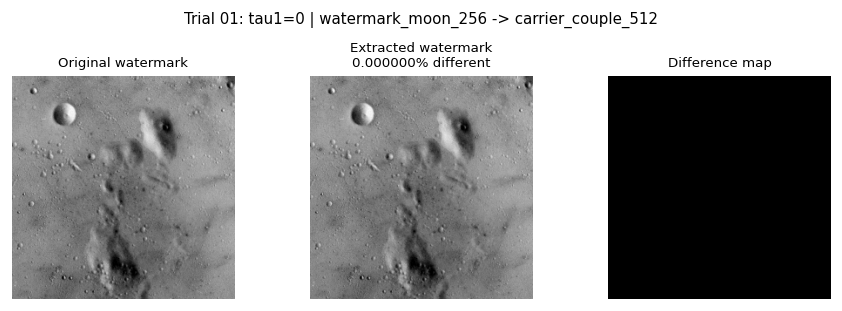

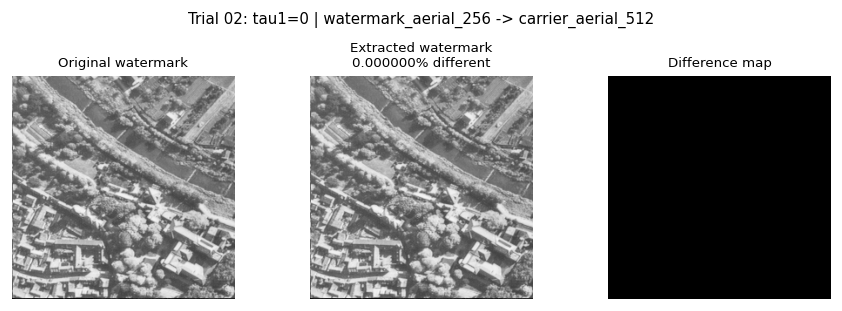

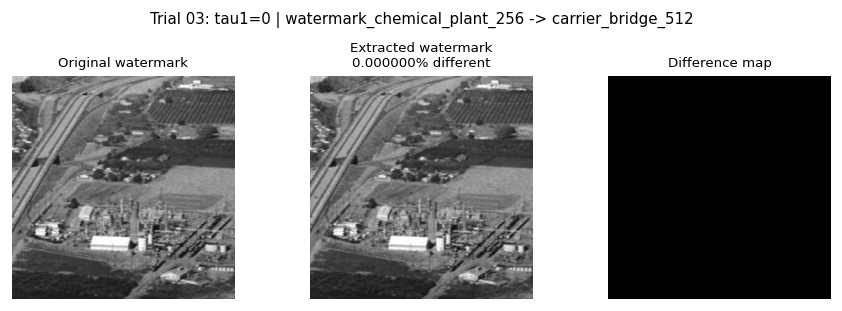

tau1=1,tau2=1: showing 3 visual result(s)


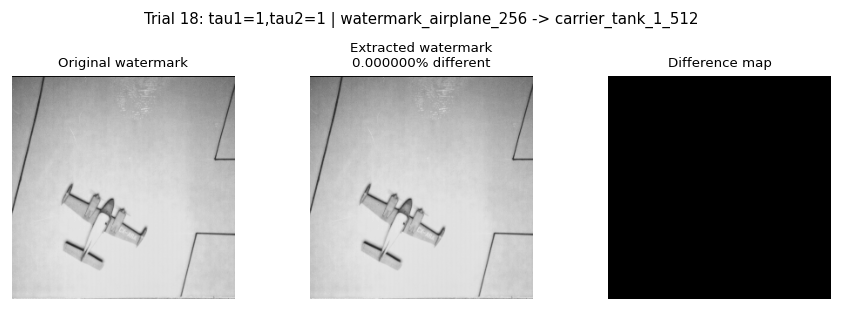

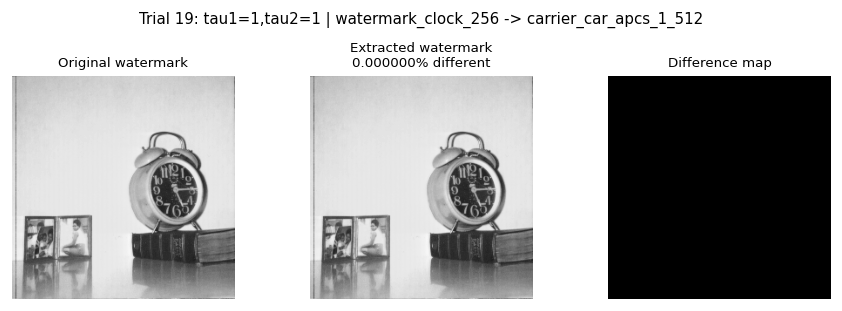

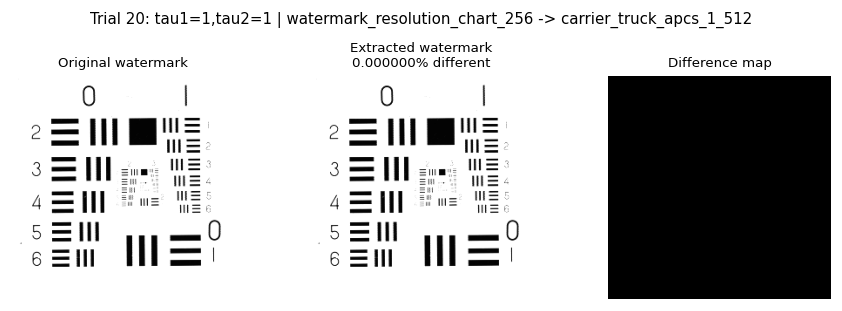

tau1=1,tau2=0: showing 3 visual result(s)


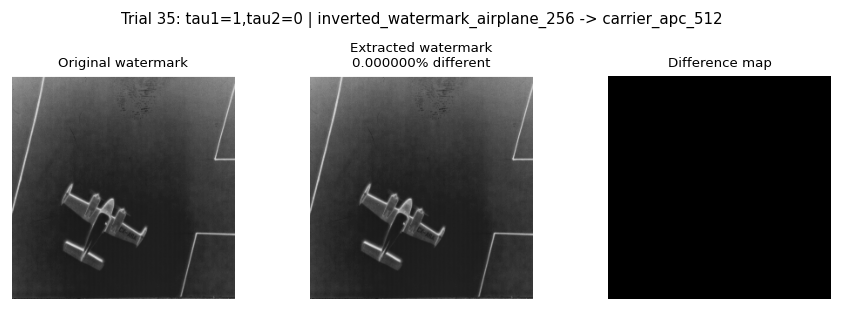

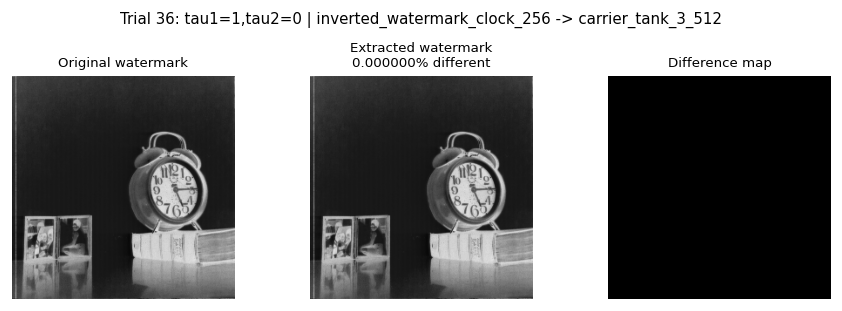

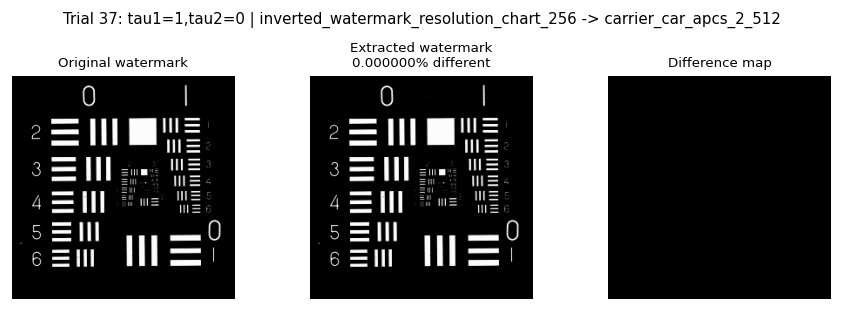

In [9]:
shown_trial_ids = set()
for branch in available_branches:
    branch_records = [record for record in records if record["branch"] == branch]
    shown_records = branch_records[:MAX_IMAGE_RESULTS_PER_BRANCH]
    print(f"{branch}: showing {len(shown_records)} visual result(s)")
    for record in shown_records:
        shown_trial_ids.add(record["trial_id"])
        show_result(record)


In [10]:
remaining_records = [record for record in records if record["trial_id"] not in shown_trial_ids]
print(f"Non-displayed trial difference rates: {len(remaining_records)} trial(s)")
print("trial branch        watermark                           carrier                    diff_%")
for record in remaining_records:
    print(
        f"{record['trial_id']:>5} {record['branch']:<13} "
        f"{record['watermark_key']:<35} {record['carrier_key']:<26} "
        f"{record['diff_percent']:>10.6f}"
    )


Non-displayed trial difference rates: 41 trial(s)
trial branch        watermark                           carrier                    diff_%
    4 tau1=0        watermark_moon_256                  carrier_truck_512            0.000000
    5 tau1=0        watermark_aerial_256                carrier_airplane_512         0.000000
    6 tau1=0        watermark_chemical_plant_256        carrier_tank_1_512           0.000000
    7 tau1=0        watermark_moon_256                  carrier_car_apcs_1_512       0.000000
    8 tau1=0        watermark_aerial_256                carrier_truck_apcs_1_512     0.000000
    9 tau1=0        watermark_chemical_plant_256        carrier_truck_apcs_2_512     0.000000
   10 tau1=0        watermark_moon_256                  carrier_tank_2_512           0.000000
   11 tau1=0        watermark_aerial_256                carrier_apc_512              0.000000
   12 tau1=0        watermark_chemical_plant_256        carrier_tank_3_512           0.000000
   13 tau1=0  